# データ品質のゲート: ステージング、ポリシー、プレビューできる修復

壊れたベンダーファイルに気づく場所として最悪なのが、P&L の会議です。

それを防ぐパターンは、バージョン管理をひとひねり加えた昔ながらの ETL の知恵です。
**配信はすべてステージングのテーブルに着地させ、ゲートを走らせ、通ったときだけ本番へ昇格
させる。**

h5i-db は各段階を説明可能にします。壊れた生の配信はステージングのバージョンとして記録に残り
ます。恥ではなく証拠です。修正はプレビューできる plan/apply の変更を通り、変更前後のサンプル
が付きます。そしてデータベース層のポリシーが、破壊的な直接書き込みを*気軽にはできないもの*
にします。人にとってもパイプラインのエージェントにとってもです。

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa
import h5i_db
from h5i_db import col, count_star, lit, when

import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("prod_dq"), create=True)

## 1. データ

`cu.make_daily_prices` が返すのは20銘柄・約1年ぶんの日足で、1行が1銘柄1セッションです。

| 列 | 型 | 意味 |
| --- | --- | --- |
| `ts` | `timestamp[us, tz=UTC]` | 引け時刻、20:00 UTC |
| `symbol` | `string` | 銘柄コード、`STK000` 〜 `STK019` |
| `open`、`high`、`low`、`close` | `float64` | セッションの価格 |
| `volume` | `int64` | 出来高（株数） |

In [2]:
UNIVERSE = [f"STK{i:03d}" for i in range(20)]
panel = cu.make_daily_prices(symbols=UNIVERSE, days=250).to_pandas()
print(f"{len(panel):,} rows x {panel.shape[1]} columns, {len(UNIVERSE)} symbols")
panel.head()

5,000 rows x 7 columns, 20 symbols


,ts,symbol,open,high,low,close,volume
0,2023-01-02 20:00:00+00:00,STK000,51.28,51.30,50.89,51.04,526289
1,2023-01-02 20:00:00+00:00,STK001,283.45,284.02,282.00,283.46,448788
2,2023-01-02 20:00:00+00:00,STK002,193.62,194.47,193.38,194.18,1295946
3,2023-01-02 20:00:00+00:00,STK003,111.66,111.94,111.24,111.48,539043
4,2023-01-02 20:00:00+00:00,STK004,221.85,221.99,220.91,221.25,466686


最後の1セッションを除くすべてが `prices_prod` の本番履歴になります。ベンダーの次のファイルは
`vendor_staging` に着地します。同じスキーマで別のテーブルなので、検査を通っていないものが
本番に触れることはありません。

In [3]:
sessions = np.sort(panel["ts"].unique())
delivery_ts = sessions[-1]                      # today's file
history = panel[panel["ts"] < delivery_ts]
delivery_true = panel[panel["ts"] == delivery_ts]  # what the vendor SHOULD send

schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("close", pa.float64()),
        pa.field("volume", pa.int64()),
    ]
)
cols = ["ts", "symbol", "close", "volume"]
for t in ("prices_prod", "vendor_staging"):
    db.create_table(t, schema, time_column="ts", sort_key=["ts", "symbol"])

db.append(
    "prices_prod",
    pa.Table.from_pandas(history[cols].sort_values(["ts", "symbol"]), schema=schema,
                         preserve_index=False),
    note="production history backfill",
)
db.table("prices_prod").select(rows=count_star(), sessions=col("ts").n_unique()).to_pandas()

,rows,sessions
0,4980,249


## 2. まずデータベースを締める

`set_policy` は、*直接*の変更経路にゲートを掛けるデータベース全体のフラグを切り替えます。

`direct_write` と `direct_delete` を切ると、言い直しも削除も plan/apply の流れを通らなければ
なりません。プレビューでき、ノートが付き、競合も確認される流れです。取り込みジョブが本来
やるべき唯一の操作である素の `append` は開いたままです。

パイプラインを cron ジョブや LLM エージェントが駆動するときに欲しいのが、このガードレール
です。破壊的な経路が、そもそも呼べません。Python API では削除はすでにプラン専用ですが、この
フラグは CLI と将来の直接経路もカバーします。

In [4]:
db.set_policy(direct_write=False, direct_delete=False)

{'direct_append': True,
 'direct_write': False,
 'direct_replace': True,
 'direct_delete': False,
 'direct_restore': True,
 'direct_compact': True}

## 3. 今日の配信は4通りに壊れている

ベンダーのファイルはユニバースが半分欠け、マイナスの価格が1つ、NULL が1つ、そして重複行が
2つあります。

これをそのままステージングに着地させます。生のファイルが書き換え不能なステージングの
バージョンになります。チケットを切るときにベンダーへ見せたいのは、まさにこれです。

In [5]:
corrupt = delivery_true[delivery_true["symbol"].isin(UNIVERSE[:10])].copy()
corrupt.loc[corrupt.index[2], "close"] = -1.0          # sign-flip fat finger
corrupt.loc[corrupt.index[5], "close"] = np.nan        # null print
corrupt = pd.concat([corrupt, corrupt.iloc[[7, 8]]])   # duplicated rows

db.append(
    "vendor_staging",
    pa.Table.from_pandas(corrupt[cols].sort_values(["ts", "symbol"]), schema=schema,
                         preserve_index=False),
    note=f"vendor delivery {pd.Timestamp(delivery_ts).date()} (raw, unvetted)",
)
corrupt[cols].head(8)

,ts,symbol,close,volume
4980,2023-12-15 20:00:00+00:00,STK000,63.27,835178
4981,2023-12-15 20:00:00+00:00,STK001,403.93,258070
4982,2023-12-15 20:00:00+00:00,STK002,-1.00,630303
4983,2023-12-15 20:00:00+00:00,STK003,143.29,287608
4984,2023-12-15 20:00:00+00:00,STK004,198.19,302340
4985,2023-12-15 20:00:00+00:00,STK005,NaN,602331
4986,2023-12-15 20:00:00+00:00,STK006,85.64,207796
4987,2023-12-15 20:00:00+00:00,STK007,173.72,721503


## 4. ゲート: 5つの検査、すべてステージングに対する SQL

検査は5つ。期待するユニバースに対する充足、NULL の健全性、価格の健全性、重複の検出、そして
本番の過去20セッションの平均に対する行数の比較です。最後の1つは安上がりですがよく効く、
「ベンダーが半分のファイルを送ってきていないか」の警報になります。

どの検査も*ステージングテーブルの現在のバージョン*を読むので、ゲートの結果はそのバージョンに
対して永久に再現できます。

In [6]:
def run_gate(day: str) -> pd.DataFrame:
    stat = (
        db.table("vendor_staging")
        .filter(col("ts") >= f"{day}T00:00:00Z", col("ts") < f"{day}T23:59:59Z")
        .select(
            rows=count_star(),
            symbols=col("symbol").n_unique(),
            null_closes=when(col("close").is_null()).then(lit(1)).otherwise(lit(0)).sum(),
            px_min=col("close").min(),
        )
        .to_pandas()
        .iloc[0]
    )
    trailing = (
        db.table("prices_prod")
        .group_by("ts")
        .count("n")
        .sort("ts", descending=True)
        .limit(20)
        .select(avg_rows=col("n").mean())
        .to_pandas()["avg_rows"]
        .iloc[0]
    )

    rows, symbols = int(stat["rows"]), int(stat["symbols"])
    checks = [
        ("universe complete", symbols == len(UNIVERSE), f"{symbols}/{len(UNIVERSE)} symbols"),
        ("no null prices", int(stat["null_closes"]) == 0, f"{int(stat['null_closes'])} nulls"),
        ("prices positive", bool(stat["px_min"] > 0), f"min close {stat['px_min']}"),
        ("no duplicate rows", rows == symbols, f"{rows} rows / {symbols} distinct"),
        ("row count vs history", abs(rows - trailing) / trailing < 0.2,
         f"{rows} vs trailing avg {trailing:.0f}"),
    ]
    return pd.DataFrame(checks, columns=["check", "passed", "detail"])

day = str(pd.Timestamp(delivery_ts).date())
gate_raw = run_gate(day)
print(f"gate verdict: {'PROMOTE' if gate_raw['passed'].all() else 'REJECT - hold in staging'}")
gate_raw

gate verdict: REJECT - hold in staging


,check,passed,detail
0,universe complete,False,10/20 symbols
1,no null prices,False,1 nulls
2,prices positive,False,min close -1.0
3,no duplicate rows,False,12 rows / 10 distinct
4,row count vs history,False,12 vs trailing avg 20


## 5. ポリシーが不可能にする近道

つい手が伸びる修正が「訂正版でステージングを上書きすればいい」です。`direct_write` を切って
あれば、その経路は `PolicyError` を上げますし、エラーのヒントが公認の流れを指します。もう
誰も、レビューを経ない `write()` で午前2時に本番データを直したりしません。

In [7]:
fixed = pa.Table.from_pandas(delivery_true[cols].sort_values(["ts", "symbol"]),
                             schema=schema, preserve_index=False)
try:
    db.write("vendor_staging", fixed)
except h5i_db.PolicyError as e:
    print(f"PolicyError  code={e.code}  retryable={e.retryable}")
    print(f"hint: {e.hint}")

PolicyError  code=policy_violation  retryable=False
hint: run the write with --plan to preview it, review, then `h5i-db plan apply`; or relax the policy with `h5i-db policy set`


## 6. 公認のやり方で直す: プラン、確認、適用

`plan_replace_range` が、壊れた日の窓に対して訂正版の配信をステージします。範囲の境界は生の
**マイクロ秒**で、時刻列の単位に合わせます。

プランはコミットではありません。サマリと変更前後のサンプルを持っていて、目で確認したり変更
チケットに添付したりできます。`apply()` がそれをアトミックに公開するのはそのあとです。

適用は競合が確認されます。そのあいだに誰かがステージングにコミットしていれば、上書きする
かわりに適用が失敗します。

In [8]:
day_start_us = int(pd.Timestamp(delivery_ts).value // 1000)
plan = db.plan_replace_range(
    "vendor_staging", day_start_us, day_start_us + 1,
    data=fixed, note=f"vendor re-delivery {day}: full universe, corrected prices",
)
plan.summary

{'rows_before': 12,
 'rows_after': 20,
 'rows_affected': 12,
 'segments_reused': 0,
 'segments_added': 1,
 'added_bytes': 1816,
 'affected_time_range': [1702670400000000, 1702670400000001]}

In [9]:
print("BEFORE (broken rows in the affected window):")
print(plan.before_sample.to_pandas().head(6).to_string(index=False))
print("\nAFTER (corrected delivery):")
print(plan.after_sample.to_pandas().head(6).to_string(index=False))

BEFORE (broken rows in the affected window):
                       ts symbol  close  volume
2023-12-15 20:00:00+00:00 STK000  63.27  835178
2023-12-15 20:00:00+00:00 STK001 403.93  258070
2023-12-15 20:00:00+00:00 STK002  -1.00  630303
2023-12-15 20:00:00+00:00 STK003 143.29  287608
2023-12-15 20:00:00+00:00 STK004 198.19  302340
2023-12-15 20:00:00+00:00 STK005    NaN  602331

AFTER (corrected delivery):
                       ts symbol  close  volume
2023-12-15 20:00:00+00:00 STK000  63.27  835178
2023-12-15 20:00:00+00:00 STK001 403.93  258070
2023-12-15 20:00:00+00:00 STK002 157.64  630303
2023-12-15 20:00:00+00:00 STK003 143.29  287608
2023-12-15 20:00:00+00:00 STK004 198.19  302340
2023-12-15 20:00:00+00:00 STK005  23.48  602331


In [10]:
result = plan.apply()
{k: result[k] for k in ("sequence", "op", "rows_total")}

{'sequence': 2, 'op': 'replace_range', 'rows_total': 20}

## 7. ゲートを走らせ直し、昇格させる

ゲートが通ったので、配信日の行を本番に追記します。ノートが、この昇格をゲートを通った配信に
結びつけます。

2つのテーブルのバージョン履歴を合わせると、話の全体が読めます。壊れた生のファイル、プレビュー
した修正、ゲートを通った昇格。

In [11]:
gate_fixed = run_gate(day)
assert gate_fixed["passed"].all(), "gate must pass after remediation"
print("gate verdict: PROMOTE")

staged = (
    db.table("vendor_staging")
    .filter(col("ts") >= f"{day}T00:00:00Z")
    .select("ts", "symbol", "close", "volume")
    .sort(["ts", "symbol"])
    .to_arrow()
)
db.append("prices_prod", staged.cast(schema), note=f"promoted gated delivery {day}")

[
    {k: v.get(k) for k in ("sequence", "op", "rows", "note")}
    for v in db.versions("vendor_staging") + db.versions("prices_prod")
    if v["op"] != "create"
]

gate verdict: PROMOTE


[{'sequence': 1,
  'op': 'append',
  'rows': 12,
  'note': 'vendor delivery 2023-12-15 (raw, unvetted)'},
 {'sequence': 2,
  'op': 'replace_range',
  'rows': 20,
  'note': 'vendor re-delivery 2023-12-15: full universe, corrected prices'},
 {'sequence': 1,
  'op': 'append',
  'rows': 4980,
  'note': 'production history backfill'},
 {'sequence': 2,
  'op': 'append',
  'rows': 5000,
  'note': 'promoted gated delivery 2023-12-15'}]

## 8. ゲートのレポートをダッシュボード風に

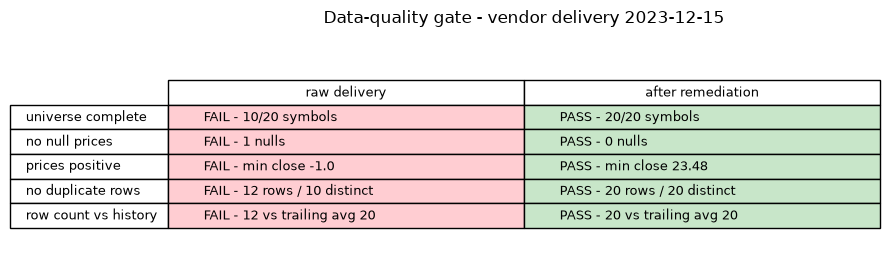

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.axis("off")
col_labels = ["raw delivery", "after remediation"]
cell_text, cell_colors = [], []
for i in range(len(gate_raw)):
    row_text, row_colors = [], []
    for g in (gate_raw, gate_fixed):
        ok = bool(g.loc[i, "passed"])
        row_text.append(("PASS - " if ok else "FAIL - ") + g.loc[i, "detail"])
        row_colors.append("#c8e6c9" if ok else "#ffcdd2")
    cell_text.append(row_text)
    cell_colors.append(row_colors)

tbl = ax.table(cellText=cell_text, cellColours=cell_colors,
               rowLabels=gate_raw["check"].tolist(), colLabels=col_labels,
               loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)
ax.set_title(f"Data-quality gate - vendor delivery {day}", pad=18)
fig.tight_layout()

## まとめ

- ステージング、ゲート、昇格という流れがパターンで、h5i-db が領収証を足します。壊れた生の
  ファイルも、プレビューした修正も、昇格も、すべて*ノート付きのバージョン*なので、インシデント
  レポートは `versions()` から勝手に書き上がります。
- `set_policy(direct_write=False, direct_delete=False)` は「本番を直で直さないでください」を、
  お願いから `PolicyError` に変えます。append は開いたままなので、取り込みは流れ続けます。
- `plan_replace_range` は `summary` と変更前後のサンプルによるドライランを与え、そのあとに
  アトミックで競合確認つきの `apply()` が来ます。プランの範囲の境界が生のマイクロ秒である
  ことを忘れずに。
- 行数を過去の履歴と比べる検査は、いちばん安上がりでいちばん検出率の高いゲートです。半分の
  ファイルや二重送信は、微妙な破損よりずっとよく起きます。

In [13]:
db.close()